# SHL Spoken Grammar Scoring — v3 (transcript-first pipeline)

**Core idea.** The labels measure *grammar*. Grammar lives in the words people say, not in the spectral shape of the audio. So this pipeline puts the transcript at the center and treats acoustics as a secondary signal:

1. **ASR.** Whisper `large-v3` (via `faster-whisper`) transcribes each clip. A disfluent `initial_prompt` stops Whisper from silently "fixing" the speaker's grammar, and per-word timestamps and confidences are kept.
2. **Grammar features from the transcript.**
   * A RoBERTa model fine-tuned on **CoLA** (Corpus of Linguistic Acceptability) gives a *grammatical acceptability probability for every sentence*. These are aggregated per clip as mean, min, and fraction of unacceptable sentences.
   * The same model's pooled hidden state serves as a 768-d grammar-aware embedding of the full transcript.
   * Simple fluency statistics come from Whisper's word timestamps: speech rate, pauses, fillers, and ASR confidence.
3. **Audio embedding.** Self-supervised speech model `WavLM-base-plus`, mean-pooled, captures pronunciation and fluency cues the transcript misses.
4. **Models.** Each feature block gets a small, regularised model (Ridge / SVR / LightGBM). With 769 samples and hundreds of dimensions, linear models on embeddings are far less prone to overfitting than boosted trees.
5. **Stacking.** A non-negative linear blend of the block-level out-of-fold predictions produces the final score.
6. **Evaluation.** 3×5 repeated stratified CV with out-of-fold Pearson r and RMSE, plus the compulsory training RMSE.

## 0. Setup
Run on a GPU runtime (Kaggle: *Accelerator → GPU T4/P100*, *Internet → On*). The data path is found automatically, so just use **Run All**.

In [1]:
!pip -q install faster-whisper==1.0.3 librosa lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 7.9 MB/s eta 0:00:0000:01:00:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
import os, re, glob, json, warnings, numpy as np, pandas as pd, torch, librosa
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
warnings.filterwarnings("ignore")

# ---------------- CONFIG: edit paths for your environment ----------------
DATA_DIR   = None   # leave None: auto-detected by searching /kaggle/input (or ./) for train.csv
TRAIN_AUDIO = None   # auto-detected below if None
TEST_AUDIO  = None
CACHE_DIR  = "./cache"; os.makedirs(CACHE_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
# -------------------------------------------------------------------------

def find_data_dir():
    # Search common roots for the folder that contains both train.csv and test.csv.
    for root in ["/kaggle/input", "/content", "."]:
        for f in glob.glob(f"{root}/**/train.csv", recursive=True):
            d = os.path.dirname(f)
            if os.path.exists(f"{d}/test.csv"): return d
    raise FileNotFoundError("train.csv not found - attach the competition data (right panel → Add Input)")

DATA_DIR = DATA_DIR or find_data_dir()

def find_audio_dir(split):
    # Find the folder holding the split's .wav files (dataset layouts differ slightly).
    cands = [d for d in glob.glob(f"{DATA_DIR}/**/", recursive=True)
             if os.path.basename(os.path.normpath(d)).lower() == split and glob.glob(d + "*.wav")]
    assert cands, f"no {split} audio dir found under {DATA_DIR}"
    return cands[0]

TRAIN_AUDIO = TRAIN_AUDIO or find_audio_dir("train")
TEST_AUDIO  = TEST_AUDIO  or find_audio_dir("test")
train = pd.read_csv(f"{DATA_DIR}/train.csv"); test = pd.read_csv(f"{DATA_DIR}/test.csv")
train["path"] = TRAIN_AUDIO + "/" + train.filename
test["path"]  = TEST_AUDIO  + "/" + test.filename
print(DEVICE, TRAIN_AUDIO, TEST_AUDIO, train.shape, test.shape)

cuda /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/ /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/ (769, 3) (216, 3)


## 1. Quick EDA
Note the **37 clips labelled 0**. A score of 0 is not in the rubric, so these are most likely empty, silent, or off-task recordings. Check a few by listening and by reading their transcripts (Section 2). If transcripts are near-empty, the `n_words` and `no_speech` features will let the model learn this group cheaply.

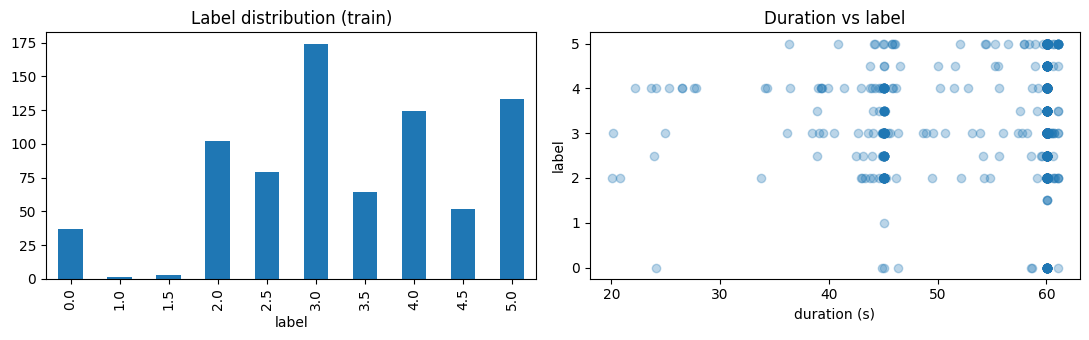

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
train.label.value_counts().sort_index().plot.bar(ax=ax[0], title="Label distribution (train)")
dur = [librosa.get_duration(path=p) for p in train.path]
ax[1].scatter(dur, train.label, alpha=.3); ax[1].set(xlabel="duration (s)", ylabel="label", title="Duration vs label")
plt.tight_layout(); plt.show()

## 2. Transcription (Whisper large-v3)
Two choices here matter more than any model tuning:
* **Model size.** `tiny.en` (used in v2) has a high word error rate on non-native speech. Its errors are noise that drowns the grammar signal. `large-v3` is far more accurate.
* **Verbatim bias.** Whisper is trained to output clean text, so it tends to *correct* grammar errors and drop fillers, which erases exactly what we need to measure. Giving it a disfluent `initial_prompt` nudges it toward verbatim output. `condition_on_previous_text=False` prevents repetition loops on long clips.

Results are cached to CSV, so this step runs once (~15–25 min on a T4).

In [4]:
!pip install -q faster-whisper
from faster_whisper import WhisperModel
PROMPT = "Umm, so, uh, I- I was going, like, to the... the market and, hmm, I buyed some things, you know."
FILLERS = {"um","umm","uh","uhh","er","ah","hmm","mm"}

def transcribe_all(df, cache):
    if os.path.exists(cache): return pd.read_csv(cache)
    asr = WhisperModel("large-v3", device=DEVICE, compute_type="float16" if DEVICE=="cuda" else "int8")
    rows = []
    for fn, p in zip(df.filename, df.path):
        audio, _ = librosa.load(p, sr=16000, mono=True)   # load audio ourselves (avoids PyAV version bug)
        segs, info = asr.transcribe(audio.astype(np.float32), language="en", beam_size=5, initial_prompt=PROMPT,
                                    condition_on_previous_text=False, word_timestamps=True)
        segs = list(segs)
        words = [w for s in segs for w in (s.words or [])]
        text = " ".join(s.text.strip() for s in segs).strip()
        dur = info.duration
        gaps = [b.start - a.end for a, b in zip(words[:-1], words[1:])]
        toks = [re.sub(r"[^a-z']", "", w.word.lower()) for w in words]
        rows.append(dict(
            filename=fn, transcript=text, duration=dur,
            n_words=len(words),
            speech_rate=len(words) / max(dur, 1),                         # words per second
            articulation_span=(words[-1].end - words[0].start) if words else 0,
            mean_pause=np.mean(gaps) if gaps else 0,
            long_pauses=sum(g > 0.7 for g in gaps) / max(len(words), 1),   # pauses >0.7s per word
            filler_rate=sum(t in FILLERS for t in toks) / max(len(words), 1),
            repeat_rate=sum(a == b and a != "" for a, b in zip(toks[:-1], toks[1:])) / max(len(words), 1),
            asr_word_conf=np.mean([w.probability for w in words]) if words else 0,
            asr_logprob=np.mean([s.avg_logprob for s in segs]) if segs else -3,
            no_speech=np.mean([s.no_speech_prob for s in segs]) if segs else 1,
        ))
        if len(rows) % 50 == 0: print(len(rows), "/", len(df))
    out = pd.DataFrame(rows); out.to_csv(cache, index=False); return out

tr_asr = transcribe_all(train, f"{CACHE_DIR}/asr_train.csv")
te_asr = transcribe_all(test,  f"{CACHE_DIR}/asr_test.csv")
tr_asr = train[["filename"]].merge(tr_asr, on="filename", how="left")   # guarantee row alignment
te_asr = test[["filename"]].merge(te_asr,  on="filename", how="left")
assert (tr_asr.filename.values == train.filename.values).all() and (te_asr.filename.values == test.filename.values).all()
for i in train.sort_values("label").index[[0, 300, 768]]:
    print(train.label[i], "|", tr_asr.transcript[i][:200], "\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 59.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 54.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 83.0 MB/s eta 0:00:00:00:0100:01


50 / 769
100 / 769
150 / 769
200 / 769
250 / 769
300 / 769
350 / 769
400 / 769
450 / 769
500 / 769
550 / 769
600 / 769
650 / 769
700 / 769
750 / 769
50 / 216
100 / 216
150 / 216
200 / 216
0.0 | I'm going to tell you about this thing at the product market. The product market is full of people and selling and buying these vegetables, or vegetables. In the market, you can find vegetables, but p 

3.0 | The best day in my life is my sister's marriage. I enjoyed a lot in that day. I learned so many things, uh, during the works. I participated, uh, for my sister's marriage. So many people came and I- I 

5.0 | The journey to Switzerland is an adventure in itself, whether you arrive by plane, train, or car. If you fly into Zurich or Genoa, you will be greeted by stunning views of the Swiss Alps as your plane 



## 3. Grammar features from the transcript (CoLA acceptability model)
`textattack/roberta-base-CoLA` is RoBERTa fine-tuned to classify whether an English sentence is grammatically acceptable. It is a direct, explainable proxy for the rubric. For each clip we compute:
* **Sentence-level acceptability** `P(acceptable)` per sentence, aggregated as mean, min, standard deviation, length-weighted mean, and the fraction below 0.5.
* **A transcript embedding.** This is the mean-pooled last hidden layer of the same model over the full transcript (one 768-d vector per clip). Because the model was trained on grammaticality, this embedding is more grammar-focused than a generic sentence embedding.

The sanity check below should give a clearly higher probability to the correct sentence.

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
COLA = "textattack/roberta-base-CoLA"
tok = AutoTokenizer.from_pretrained(COLA)
cola = AutoModelForSequenceClassification.from_pretrained(COLA, output_hidden_states=True).to(DEVICE).eval()

@torch.no_grad()
def cola_forward(texts, bs=32):
    probs, embs = [], []
    for i in range(0, len(texts), bs):
        enc = tok(texts[i:i+bs], padding=True, truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
        out = cola(**enc)
        probs.append(out.logits.softmax(-1)[:, 1].cpu().numpy())          # label 1 = acceptable
        h, m = out.hidden_states[-1], enc.attention_mask.unsqueeze(-1)
        embs.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())            # masked mean pooling
    return np.concatenate(probs), np.concatenate(embs)

print(cola_forward(["She went to school yesterday.", "She go to school yesterday."])[0])

def split_sents(t):
    t = t if isinstance(t, str) else ""
    s = [x.strip() for x in re.split(r"(?<=[.!?])\s+", t) if len(x.split()) >= 3]
    return s or ([t] if t.strip() else ["."])

def grammar_block(asr):
    sents = [split_sents(t) for t in asr.transcript]
    flat = [s for ss in sents for s in ss]
    p, _ = cola_forward(flat)
    feats, k = [], 0
    for ss in sents:
        pi, li = p[k:k+len(ss)], np.array([len(s.split()) for s in ss]); k += len(ss)
        feats.append(dict(cola_mean=pi.mean(), cola_min=pi.min(), cola_std=pi.std(),
                          cola_wmean=(pi*li).sum()/li.sum(), cola_bad_frac=(pi < .5).mean(),
                          n_sents=len(ss), words_per_sent=li.mean()))
    _, emb = cola_forward([t if isinstance(t, str) and t.strip() else "." for t in asr.transcript], bs=16)
    return pd.DataFrame(feats), emb

tr_gram, tr_temb = grammar_block(tr_asr)
te_gram, te_temb = grammar_block(te_asr)
for c in ["cola_mean", "cola_wmean", "cola_bad_frac", "n_words", "speech_rate", "asr_word_conf"]:
    v = (tr_gram if c in tr_gram else tr_asr)[c]
    print(f"{c:15s} r = {pearsonr(v, train.label)[0]:+.3f}")

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-CoLA
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0.96808183 0.5120462 ]
cola_mean       r = +0.384
cola_wmean      r = +0.370
cola_bad_frac   r = -0.354
n_words         r = +0.264
speech_rate     r = +0.218
asr_word_conf   r = +0.691


## 4. Audio embedding (WavLM)
`microsoft/wavlm-base-plus` is a self-supervised speech model. We average its hidden states over time and over all layers. Middle layers carry phonetic and fluency information, so averaging layers is a simple, robust choice. Audio is processed in 20 s chunks to keep memory flat.

In [6]:
from transformers import AutoFeatureExtractor, WavLMModel
fe = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base-plus").to(DEVICE).eval()

@torch.no_grad()
def wavlm_embed(paths, cache):
    if os.path.exists(cache): return np.load(cache)
    out = []
    for p in paths:
        y, _ = librosa.load(p, sr=16000, mono=True)
        if len(y) < 16000: y = np.pad(y, (0, 16000 - len(y)))
        vecs, wts = [], []
        for s in range(0, len(y), 20 * 16000):
            ch = y[s:s + 20 * 16000]
            if len(ch) < 8000: continue
            x = fe(ch, sampling_rate=16000, return_tensors="pt").input_values.to(DEVICE)
            hs = torch.stack(wavlm(x, output_hidden_states=True).hidden_states)  # (L, 1, T, D)
            vecs.append(hs.mean(dim=(0, 2)).squeeze(0).cpu().numpy()); wts.append(len(ch))
        out.append(np.average(vecs, axis=0, weights=wts))
    out = np.stack(out); np.save(cache, out); return out

tr_aemb = wavlm_embed(train.path, f"{CACHE_DIR}/wavlm_train.npy")
te_aemb = wavlm_embed(test.path,  f"{CACHE_DIR}/wavlm_test.npy")
print(tr_aemb.shape, te_aemb.shape)

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

(769, 768) (216, 768)


## 5. Feature blocks and models
| Block | Content | Model |
|---|---|---|
| `scalar` | CoLA aggregates + fluency/ASR statistics (~19 features) | LightGBM (shallow) and Ridge |
| `text_emb` | 768-d CoLA-RoBERTa transcript embedding | Ridge and SVR |
| `audio_emb` | 768-d WavLM embedding | Ridge |

**Validation.** 5-fold CV stratified on binned labels, repeated 3× with different seeds. Out-of-fold (OOF) predictions are averaged over repeats. Test predictions are the average of all 15 fold models.

**Stacking.** A non-negative linear regression on the OOF predictions of each base model. The stacker's own score is itself measured by cross-validation, so the reported number is not optimistic.

In [7]:
SCALAR_COLS = ["n_words","speech_rate","articulation_span","mean_pause","long_pauses","filler_rate",
               "repeat_rate","asr_word_conf","asr_logprob","no_speech"]
Xs_tr = pd.concat([tr_gram, tr_asr[SCALAR_COLS]], axis=1).fillna(0).values
Xs_te = pd.concat([te_gram, te_asr[SCALAR_COLS]], axis=1).fillna(0).values
y = train.label.values
bins = np.digitize(y, [1.75, 2.75, 3.75, 4.75])          # 5 strata; merges the rare 0–1.5 scores
ALPHAS = np.logspace(-2, 5, 30)

BASES = {
  "scalar_lgbm": (Xs_tr, Xs_te, lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.02, num_leaves=8,
                     min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1)),
  "scalar_ridge": (Xs_tr, Xs_te, lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))),
  "text_ridge":  (tr_temb, te_temb, lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))),
  "text_svr":    (tr_temb, te_temb, lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.2))),
  "audio_ridge": (tr_aemb, te_aemb, lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))),
}

def metrics(t, p): return pearsonr(t, p)[0], np.sqrt(mean_squared_error(t, p))

N_REP, K = 3, 5
oof = {n: np.zeros(len(y)) for n in BASES}; tst = {n: np.zeros(len(test)) for n in BASES}
for rep in range(N_REP):
    skf = StratifiedKFold(K, shuffle=True, random_state=SEED + rep)
    for tri, vai in skf.split(Xs_tr, bins):
        for n, (Xtr, Xte, mk) in BASES.items():
            m = mk().fit(Xtr[tri], y[tri])
            oof[n][vai] += m.predict(Xtr[vai]) / N_REP
            tst[n] += m.predict(Xte) / (N_REP * K)

res = pd.DataFrame({n: metrics(y, oof[n]) for n in BASES}, index=["Pearson r (OOF)", "RMSE (OOF)"]).T
res

,Pearson r (OOF),RMSE (OOF)
scalar_lgbm,0.767744,0.793670
scalar_ridge,0.752063,0.816904
text_ridge,0.676795,0.911989
text_svr,0.672993,0.917617
audio_ridge,0.888385,0.568534


In [8]:
# ---- Stacking: non-negative linear blend of base-model OOF predictions ----
O, T = np.column_stack([oof[n] for n in BASES]), np.column_stack([tst[n] for n in BASES])
stack_oof = np.zeros(len(y))
for tri, vai in StratifiedKFold(K, shuffle=True, random_state=SEED).split(O, bins):   # honest stack score
    stack_oof[vai] = LinearRegression(positive=True).fit(O[tri], y[tri]).predict(O[vai])
stacker = LinearRegression(positive=True).fit(O, y)
print("Blend weights:", dict(zip(BASES, stacker.coef_.round(3))), "intercept", round(stacker.intercept_, 3))
r, rmse = metrics(y, np.clip(stack_oof, 0, 5))
print(f"STACK  OOF Pearson r = {r:.4f} | OOF RMSE = {rmse:.4f}")
res.loc["STACK"] = [r, rmse]

Blend weights: {'scalar_lgbm': np.float64(0.038), 'scalar_ridge': np.float64(0.116), 'text_ridge': np.float64(0.19), 'text_svr': np.float64(0.08), 'audio_ridge': np.float64(0.77)} intercept -0.64
STACK  OOF Pearson r = 0.9067 | OOF RMSE = 0.5230


## 6. Compulsory: RMSE on the training data
Two numbers are reported, and the difference between them matters:
* **Training RMSE.** Models are refit on all 769 samples and scored on those same samples. This is what the brief asks for, but it is optimistic because the model has seen these labels.
* **OOF (cross-validated) RMSE.** Each sample is predicted by a model that never saw it. This is the honest estimate of leaderboard performance.

In [9]:
full_tr = np.column_stack([mk().fit(Xtr, y).predict(Xtr) for n, (Xtr, Xte, mk) in BASES.items()])
train_pred = np.clip(stacker.predict(full_tr), 0, 5)
tr_r, tr_rmse = metrics(y, train_pred)
print(f"TRAINING RMSE = {tr_rmse:.4f}   (training Pearson r = {tr_r:.4f})")
print(f"CV (OOF) RMSE = {res.loc['STACK','RMSE (OOF)']:.4f}   (CV Pearson r = {res.loc['STACK','Pearson r (OOF)']:.4f})")

TRAINING RMSE = 0.3423   (training Pearson r = 0.9614)
CV (OOF) RMSE = 0.5230   (CV Pearson r = 0.9067)


## 7. Diagnostics and interpretability

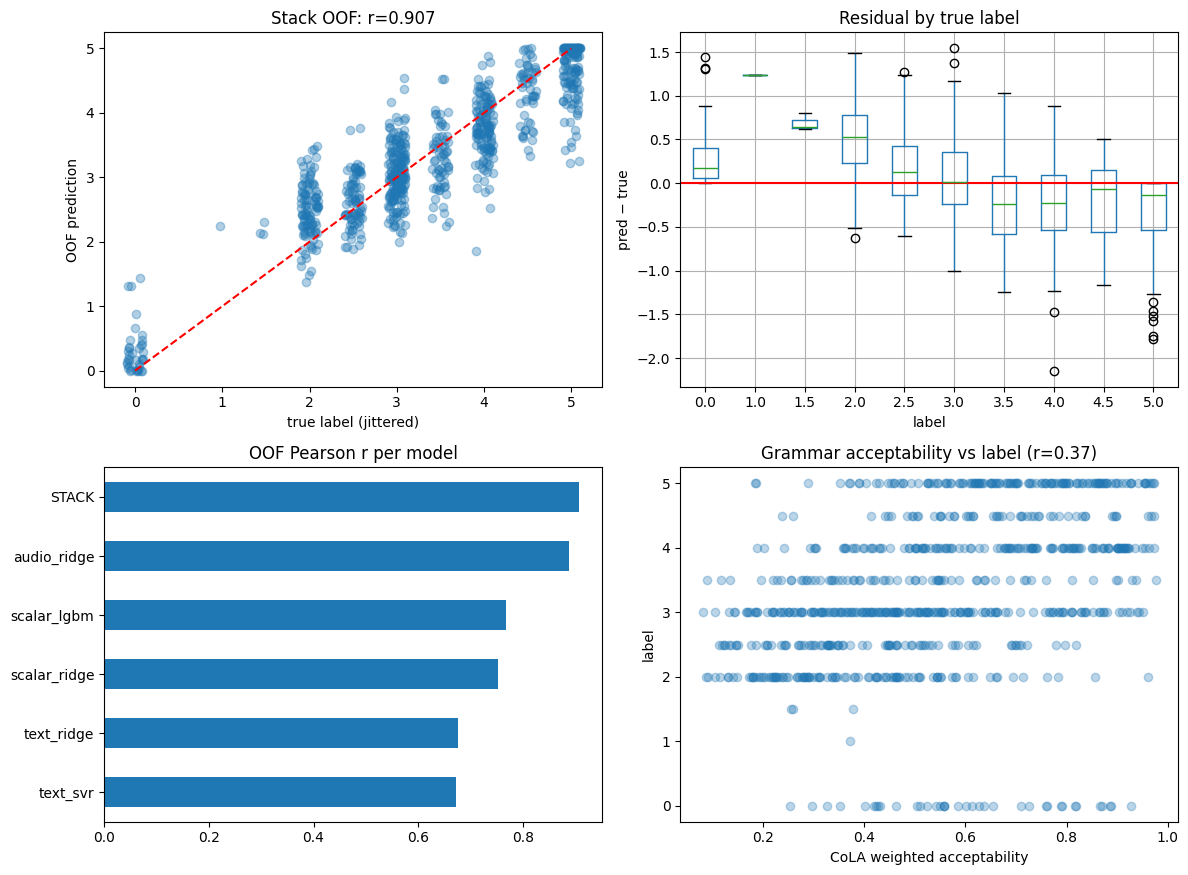

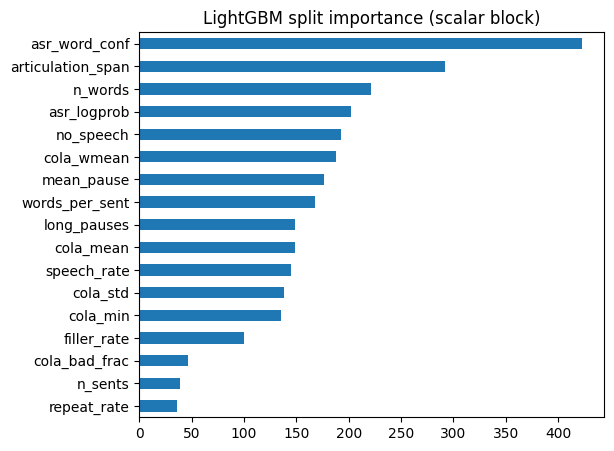

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
p = np.clip(stack_oof, 0, 5)
ax[0,0].scatter(y + np.random.uniform(-.1,.1,len(y)), p, alpha=.35); ax[0,0].plot([0,5],[0,5],"r--")
ax[0,0].set(xlabel="true label (jittered)", ylabel="OOF prediction", title=f"Stack OOF: r={res.loc['STACK'].iloc[0]:.3f}")
pd.DataFrame({"label": y, "resid": p - y}).boxplot("resid", by="label", ax=ax[0,1]); ax[0,1].axhline(0, c="r")
ax[0,1].set(title="Residual by true label", ylabel="pred − true"); fig.suptitle("")
res["Pearson r (OOF)"].sort_values().plot.barh(ax=ax[1,0], title="OOF Pearson r per model")
ax[1,1].scatter(tr_gram.cola_wmean, y, alpha=.3)
ax[1,1].set(xlabel="CoLA weighted acceptability", ylabel="label",
            title=f"Grammar acceptability vs label (r={pearsonr(tr_gram.cola_wmean, y)[0]:.2f})")
plt.tight_layout(); plt.show()

imp = pd.Series(BASES["scalar_lgbm"][2]().fit(Xs_tr, y).feature_importances_,
                index=list(tr_gram.columns) + SCALAR_COLS).sort_values()
imp.plot.barh(figsize=(6, 5), title="LightGBM split importance (scalar block)"); plt.show()

## 8. Submission

In [11]:
sub = pd.DataFrame({"filename": test.filename, "label": np.clip(stacker.predict(T), 0, 5)})
sub.to_csv("submission_v3_transcript_stack.csv", index=False)
print(sub.shape, sub.label.describe().round(3).to_dict())

(216, 2) {'count': 216.0, 'mean': 3.229, 'std': 0.868, 'min': 1.647, '25%': 2.606, '50%': 3.157, '75%': 3.74, 'max': 5.0}


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

openai/whisper-medium 100 / 769
openai/whisper-medium 200 / 769
openai/whisper-medium 300 / 769
openai/whisper-medium 400 / 769
openai/whisper-medium 500 / 769
openai/whisper-medium 600 / 769
openai/whisper-medium 700 / 769


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

openai/whisper-medium 100 / 216
openai/whisper-medium 200 / 216


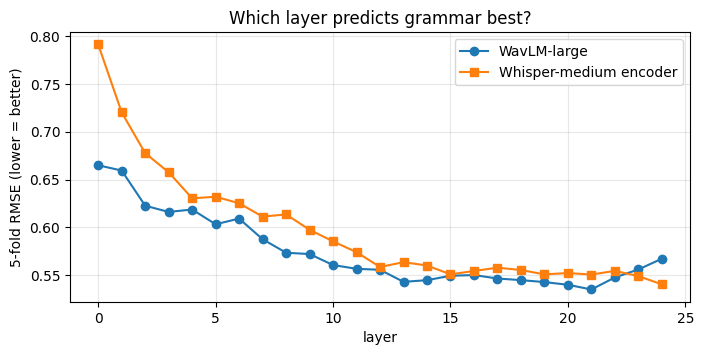

wavlmL best layers: [21, 20, 19] RMSE: [0.5352, 0.5401, 0.5429]
whisperM best layers: [24, 23, 21] RMSE: [0.5405, 0.5491, 0.5507]


,Pearson r (OOF),RMSE (OOF)
STACK,0.914204,0.502765
wavlmL_L21,0.901543,0.535897
wavlmL_L19,0.899246,0.541795
wavlmL_L20,0.898757,0.543055
whisperM_L24,0.898706,0.543636
whisperM_L23,0.893622,0.555972
whisperM_L21,0.893293,0.556559
audio_ridge,0.888385,0.568534
scalar_lgbm,0.767744,0.793670
scalar_ridge,0.752063,0.816904


Blend weights: {'scalar_ridge': np.float64(0.07), 'text_ridge': np.float64(0.171), 'text_svr': np.float64(0.017), 'audio_ridge': np.float64(0.261), 'wavlmL_L21': np.float64(0.328), 'wavlmL_L19': np.float64(0.012), 'whisperM_L24': np.float64(0.203), 'whisperM_L21': np.float64(0.091)}
OLD stack (v5): CV RMSE = 0.5230 | CV r = 0.9067
NEW stack (v6): CV RMSE = 0.5028 | CV r = 0.9142
TRAINING RMSE  = 0.3110 | training r = 0.9684


/kaggle/working/submission_v6_multi_encoder_stack.csv

In [12]:
# ===================== v6: bigger audio encoders + best-layer selection =====================
from transformers import AutoFeatureExtractor, AutoModel, WhisperFeatureExtractor
from transformers import WhisperModel as HFWhisperModel
from IPython.display import FileLink, display

def _load16k(p):
    a, _ = librosa.load(p, sr=16000, mono=True)
    return np.pad(a, (0, max(0, 16000 - len(a))))

@torch.no_grad()
def layer_embs_ssl(name, paths, cache, chunk_s=20):
    # WavLM: per-layer [mean, std] of hidden states over time
    if os.path.exists(cache): return np.load(cache)
    fe_ = AutoFeatureExtractor.from_pretrained(name)
    m_ = AutoModel.from_pretrained(name).to(DEVICE).eval()
    out = []
    for i, p in enumerate(paths):
        a = _load16k(p); acc, w = 0, 0
        for s in range(0, len(a), chunk_s * 16000):
            ch = a[s:s + chunk_s * 16000]
            if len(ch) < 8000: continue
            x = fe_(ch, sampling_rate=16000, return_tensors="pt").input_values.to(DEVICE)
            hs = torch.stack(m_(x, output_hidden_states=True).hidden_states)[:, 0]
            f = torch.cat([hs.mean(1), hs.std(1)], -1).float().cpu().numpy()
            acc = acc + f * len(ch); w += len(ch)
        out.append(acc / w)
        if (i + 1) % 100 == 0: print(name, i + 1, "/", len(paths))
    out = np.stack(out).astype(np.float32); np.save(cache, out)
    del m_; torch.cuda.empty_cache(); return out

@torch.no_grad()
def layer_embs_whisper(name, paths, cache):
    # Whisper encoder: per-layer [mean, std] over frames containing real audio
    if os.path.exists(cache): return np.load(cache)
    fe_ = WhisperFeatureExtractor.from_pretrained(name)
    enc = HFWhisperModel.from_pretrained(name).encoder.to(DEVICE).eval()
    out = []
    for i, p in enumerate(paths):
        a = _load16k(p); acc, w = 0, 0
        for s in range(0, len(a), 30 * 16000):
            ch = a[s:s + 30 * 16000]
            if len(ch) < 8000: continue
            feats = fe_(ch, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE)
            hs = torch.stack(enc(feats, output_hidden_states=True).hidden_states)[:, 0]
            n = min(1500, max(2, int(np.ceil(len(ch) / 16000 * 50))))
            hs = hs[:, :n]
            f = torch.cat([hs.mean(1), hs.std(1)], -1).float().cpu().numpy()
            acc = acc + f * len(ch); w += len(ch)
        out.append(acc / w)
        if (i + 1) % 100 == 0: print(name, i + 1, "/", len(paths))
    out = np.stack(out).astype(np.float32); np.save(cache, out)
    del enc; torch.cuda.empty_cache(); return out

# ---- 1. extract embeddings (slow part, ~30 min) ----
tr_wl = layer_embs_ssl("microsoft/wavlm-large", train.path, f"{CACHE_DIR}/wavlmL_train.npy")
te_wl = layer_embs_ssl("microsoft/wavlm-large", test.path,  f"{CACHE_DIR}/wavlmL_test.npy")
tr_wh = layer_embs_whisper("openai/whisper-medium", train.path, f"{CACHE_DIR}/whisperM_train.npy")
te_wh = layer_embs_whisper("openai/whisper-medium", test.path,  f"{CACHE_DIR}/whisperM_test.npy")

# ---- 2. find the best layers ----
def layer_scan(E):
    skf = StratifiedKFold(5, shuffle=True, random_state=7)
    rmses = []
    for l in range(E.shape[1]):
        p = np.zeros(len(y))
        for tri, vai in skf.split(E, bins):
            m = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)).fit(E[tri, l], y[tri])
            p[vai] = m.predict(E[vai, l])
        rmses.append(np.sqrt(mean_squared_error(y, p)))
    return np.array(rmses)

scan_wl, scan_wh = layer_scan(tr_wl), layer_scan(tr_wh)
plt.figure(figsize=(8, 3.5))
plt.plot(scan_wl, "o-", label="WavLM-large"); plt.plot(scan_wh, "s-", label="Whisper-medium encoder")
plt.xlabel("layer"); plt.ylabel("5-fold RMSE (lower = better)"); plt.title("Which layer predicts grammar best?")
plt.legend(); plt.grid(alpha=.3); plt.show()

for tag, Etr, Ete, sc in [("wavlmL", tr_wl, te_wl, scan_wl), ("whisperM", tr_wh, te_wh, scan_wh)]:
    best = np.argsort(sc)[:3]
    print(tag, "best layers:", best.tolist(), "RMSE:", sc[best].round(4).tolist())
    for l in best:
        BASES[f"{tag}_L{l}"] = (Etr[:, l], Ete[:, l],
                                lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)))

# ---- 3. retrain + stack ----
prev = res.loc["STACK"].copy() if "STACK" in res.index else None
oof = {n: np.zeros(len(y)) for n in BASES}; tst = {n: np.zeros(len(test)) for n in BASES}
for rep in range(N_REP):
    skf = StratifiedKFold(K, shuffle=True, random_state=SEED + rep)
    for tri, vai in skf.split(y, bins):
        for n, (Xtr, Xte, mk) in BASES.items():
            m = mk().fit(Xtr[tri], y[tri])
            oof[n][vai] += m.predict(Xtr[vai]) / N_REP
            tst[n] += m.predict(Xte) / (N_REP * K)

res = pd.DataFrame({n: metrics(y, oof[n]) for n in BASES}, index=["Pearson r (OOF)", "RMSE (OOF)"]).T
O, T = np.column_stack([oof[n] for n in BASES]), np.column_stack([tst[n] for n in BASES])
stack_oof = np.zeros(len(y))
for tri, vai in StratifiedKFold(K, shuffle=True, random_state=SEED).split(O, bins):
    stack_oof[vai] = LinearRegression(positive=True).fit(O[tri], y[tri]).predict(O[vai])
stacker = LinearRegression(positive=True).fit(O, y)
r, rmse = metrics(y, np.clip(stack_oof, 0, 5)); res.loc["STACK"] = [r, rmse]
display(res.sort_values("RMSE (OOF)"))
print("Blend weights:", {k: round(v, 3) for k, v in zip(BASES, stacker.coef_) if v > 0})

# ---- 4. training RMSE + submission ----
full_tr = np.column_stack([mk().fit(Xtr, y).predict(Xtr) for n, (Xtr, Xte, mk) in BASES.items()])
tr_r, tr_rmse = metrics(y, np.clip(stacker.predict(full_tr), 0, 5))
print("=" * 60)
if prev is not None: print(f"OLD stack (v5): CV RMSE = {prev.iloc[1]:.4f} | CV r = {prev.iloc[0]:.4f}")
print(f"NEW stack (v6): CV RMSE = {rmse:.4f} | CV r = {r:.4f}")
print(f"TRAINING RMSE  = {tr_rmse:.4f} | training r = {tr_r:.4f}")
print("=" * 60)
sub6 = pd.DataFrame({"filename": test.filename, "label": np.clip(stacker.predict(T), 0, 5)})
sub6.to_csv("submission_v6_multi_encoder_stack.csv", index=False)
display(FileLink("submission_v6_multi_encoder_stack.csv"))

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

openai/whisper-large-v3 100 / 769
openai/whisper-large-v3 200 / 769
openai/whisper-large-v3 300 / 769
openai/whisper-large-v3 400 / 769
openai/whisper-large-v3 500 / 769
openai/whisper-large-v3 600 / 769
openai/whisper-large-v3 700 / 769


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

openai/whisper-large-v3 100 / 216
openai/whisper-large-v3 200 / 216


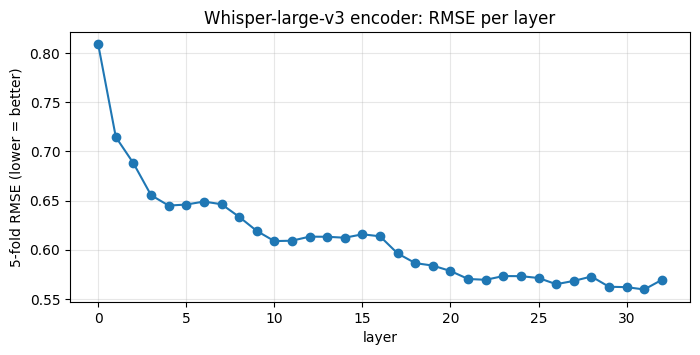

whisperL3 best layers: [31, 30, 29] RMSE: [0.5596, 0.562, 0.5624]
Blocks now: ['scalar_lgbm', 'scalar_ridge', 'text_ridge', 'text_svr', 'audio_ridge', 'wavlmL_L21', 'wavlmL_L20', 'wavlmL_L19', 'whisperM_L24', 'whisperM_L23', 'whisperM_L21', 'whisperL3_L31', 'whisperL3_L30', 'whisperL3_L29', 'wavlmL_top3_svr', 'whisperM_top3_svr', 'whisperL3_top3_svr']


,Pearson r (OOF),RMSE (OOF)
STACK,0.916758,0.495512
wavlmL_top3_svr,0.904259,0.531093
wavlmL_L21,0.901543,0.535897
wavlmL_L19,0.899246,0.541795
wavlmL_L20,0.898757,0.543055
whisperM_L24,0.898706,0.543636
whisperM_top3_svr,0.897048,0.553168
whisperM_L23,0.893622,0.555972
whisperM_L21,0.893293,0.556559
whisperL3_top3_svr,0.894132,0.557670


Blend weights: {'scalar_ridge': np.float64(0.063), 'text_ridge': np.float64(0.16), 'audio_ridge': np.float64(0.204), 'wavlmL_L21': np.float64(0.098), 'whisperM_L24': np.float64(0.147), 'wavlmL_top3_svr': np.float64(0.299), 'whisperM_top3_svr': np.float64(0.025), 'whisperL3_top3_svr': np.float64(0.166)}
OLD stack (v6): CV RMSE = 0.5028 | CV r = 0.9142
NEW stack (v7): CV RMSE = 0.4955 | CV r = 0.9168
TRAINING RMSE  = 0.2096 | training r = 0.9856


/kaggle/working/submission_v7_whisperL3_svr_stack.csv

In [19]:
# ===================== v7: Whisper-large-v3 encoder + non-linear (RBF SVR) models =====================
from sklearn.svm import SVR

@torch.no_grad()
def layer_embs_whisper(name, paths, cache):
    # Whisper encoder: per-layer [mean, std] over frames containing real audio
    if os.path.exists(cache): return np.load(cache)
    fe_ = WhisperFeatureExtractor.from_pretrained(name)
    enc = HFWhisperModel.from_pretrained(name).encoder.float().to(DEVICE).eval()   # .float(): large-v3 is stored in fp16
    out = []
    for i, p in enumerate(paths):
        a = _load16k(p); acc, w = 0, 0
        for s in range(0, len(a), 30 * 16000):
            ch = a[s:s + 30 * 16000]
            if len(ch) < 8000: continue
            feats = fe_(ch, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE)
            hs = torch.stack(enc(feats, output_hidden_states=True).hidden_states)[:, 0]
            n = min(1500, max(2, int(np.ceil(len(ch) / 16000 * 50))))
            hs = hs[:, :n]
            f = torch.cat([hs.mean(1), hs.std(1)], -1).float().cpu().numpy()
            acc = acc + f * len(ch); w += len(ch)
        out.append(acc / w)
        if (i + 1) % 100 == 0: print(name, i + 1, "/", len(paths))
    out = np.stack(out).astype(np.float32); np.save(cache, out)
    del enc; torch.cuda.empty_cache(); return out

# ---- 1. Whisper-large-v3 encoder per-layer embeddings ----
tr_wv3 = layer_embs_whisper("openai/whisper-large-v3", train.path, f"{CACHE_DIR}/whisperL3_train.npy")
te_wv3 = layer_embs_whisper("openai/whisper-large-v3", test.path,  f"{CACHE_DIR}/whisperL3_test.npy")
scan_wv3 = layer_scan(tr_wv3)
plt.figure(figsize=(8, 3.5)); plt.plot(scan_wv3, "o-")
plt.title("Whisper-large-v3 encoder: RMSE per layer"); plt.xlabel("layer"); plt.ylabel("5-fold RMSE (lower = better)")
plt.grid(alpha=.3); plt.show()
best3 = np.argsort(scan_wv3)[:3]
print("whisperL3 best layers:", best3.tolist(), "RMSE:", scan_wv3[best3].round(4).tolist())
for l in best3:
    BASES[f"whisperL3_L{l}"] = (tr_wv3[:, l], te_wv3[:, l],
                                lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)))

# ---- 2. Non-linear RBF-SVR on the average of each encoder's 3 best layers ----
for tag, Etr, Ete, sc in [("wavlmL", tr_wl, te_wl, scan_wl), ("whisperM", tr_wh, te_wh, scan_wh),
                          ("whisperL3", tr_wv3, te_wv3, scan_wv3)]:
    b = np.argsort(sc)[:3]
    BASES[f"{tag}_top3_svr"] = (Etr[:, b].mean(1), Ete[:, b].mean(1),
                                lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.1)))
print("Blocks now:", list(BASES))

# ---- 3. retrain + stack (same honest procedure as before) ----
prev = res.loc["STACK"].copy()
oof = {n: np.zeros(len(y)) for n in BASES}; tst = {n: np.zeros(len(test)) for n in BASES}
for rep in range(N_REP):
    skf = StratifiedKFold(K, shuffle=True, random_state=SEED + rep)
    for tri, vai in skf.split(y, bins):
        for n, (Xtr, Xte, mk) in BASES.items():
            m = mk().fit(Xtr[tri], y[tri])
            oof[n][vai] += m.predict(Xtr[vai]) / N_REP
            tst[n] += m.predict(Xte) / (N_REP * K)

res = pd.DataFrame({n: metrics(y, oof[n]) for n in BASES}, index=["Pearson r (OOF)", "RMSE (OOF)"]).T
O, T = np.column_stack([oof[n] for n in BASES]), np.column_stack([tst[n] for n in BASES])
stack_oof = np.zeros(len(y))
for tri, vai in StratifiedKFold(K, shuffle=True, random_state=SEED).split(O, bins):
    stack_oof[vai] = LinearRegression(positive=True).fit(O[tri], y[tri]).predict(O[vai])
stacker = LinearRegression(positive=True).fit(O, y)
r, rmse = metrics(y, np.clip(stack_oof, 0, 5)); res.loc["STACK"] = [r, rmse]
display(res.sort_values("RMSE (OOF)"))
print("Blend weights:", {k: round(v, 3) for k, v in zip(BASES, stacker.coef_) if v > 0})

# ---- 4. training RMSE + submission ----
full_tr = np.column_stack([mk().fit(Xtr, y).predict(Xtr) for n, (Xtr, Xte, mk) in BASES.items()])
tr_r, tr_rmse = metrics(y, np.clip(stacker.predict(full_tr), 0, 5))
print("=" * 60)
print(f"OLD stack (v6): CV RMSE = {prev.iloc[1]:.4f} | CV r = {prev.iloc[0]:.4f}")
print(f"NEW stack (v7): CV RMSE = {rmse:.4f} | CV r = {r:.4f}")
print(f"TRAINING RMSE  = {tr_rmse:.4f} | training r = {tr_r:.4f}")
print("=" * 60)
sub7 = pd.DataFrame({"filename": test.filename, "label": np.clip(stacker.predict(T), 0, 5)})
sub7.to_csv("submission_v7_whisperL3_svr_stack.csv", index=False)
display(FileLink("submission_v7_whisperL3_svr_stack.csv"))

In [20]:
# ===================== v8: diagnose label-0 clips, then retrain WITHOUT them =====================
p_old = np.clip(stack_oof, 0, 5); err = (p_old - y) ** 2
d = pd.DataFrame({"label": y, "pred": p_old, "sq_err": err})
g = d.groupby("label").agg(n=("sq_err", "size"), mean_pred=("pred", "mean"),
                           rmse=("sq_err", lambda e: np.sqrt(e.mean())), share_of_error=("sq_err", "sum"))
g["share_of_error"] = (g.share_of_error / err.sum()).round(3)
display(g)
z = y == 0
cols = ["n_words", "no_speech", "duration", "asr_word_conf"]
display(pd.concat({"label 0": tr_asr.loc[z, cols].mean(), "others": tr_asr.loc[~z, cols].mean()}, axis=1).round(3))
for t in tr_asr.transcript[z].head(5): print(" -", repr(str(t)[:150]))
print("v7 test predictions (min, 1%, 5%):", np.quantile(np.clip(stacker.predict(T), 0, 5), [0, .01, .05]).round(2))
old_nz = np.sqrt(mean_squared_error(y[~z], p_old[~z]))

# ---- retrain all blocks on non-zero clips only ----
keep = ~z; yk = y[keep]; bk = np.digitize(yk, [2.75, 3.75, 4.75])
oof8 = {n: np.zeros(keep.sum()) for n in BASES}; tst8 = {n: np.zeros(len(test)) for n in BASES}
for rep in range(N_REP):
    skf = StratifiedKFold(K, shuffle=True, random_state=SEED + rep)
    for tri, vai in skf.split(yk, bk):
        for n, (Xtr, Xte, mk) in BASES.items():
            Xk = Xtr[keep]
            m = mk().fit(Xk[tri], yk[tri])
            oof8[n][vai] += m.predict(Xk[vai]) / N_REP
            tst8[n] += m.predict(Xte) / (N_REP * K)
O8 = np.column_stack([oof8[n] for n in BASES]); T8 = np.column_stack([tst8[n] for n in BASES])
s8 = np.zeros(len(yk))
for tri, vai in StratifiedKFold(K, shuffle=True, random_state=SEED).split(O8, bk):
    s8[vai] = LinearRegression(positive=True).fit(O8[tri], yk[tri]).predict(O8[vai])
stacker8 = LinearRegression(positive=True).fit(O8, yk)
r8, rmse8 = metrics(yk, np.clip(s8, 0, 5))
full8 = np.column_stack([mk().fit(Xtr[keep], yk).predict(Xtr[keep]) for n, (Xtr, Xte, mk) in BASES.items()])
tr_r8, tr_rmse8 = metrics(yk, np.clip(stacker8.predict(full8), 0, 5))
print("=" * 60)
print(f"v7 (trained WITH zeros)    CV RMSE on non-zero clips = {old_nz:.4f}")
print(f"v8 (trained WITHOUT zeros) CV RMSE on non-zero clips = {rmse8:.4f} | r = {r8:.4f}")
print(f"v8 TRAINING RMSE = {tr_rmse8:.4f}")
print("=" * 60)
sub8 = pd.DataFrame({"filename": test.filename, "label": np.clip(stacker8.predict(T8), 0, 5)})
sub8.to_csv("submission_v8_no_zero_labels.csv", index=False)
display(FileLink("submission_v8_no_zero_labels.csv"))

,n,mean_pred,rmse,share_of_error
label,,,,
0.0,37,0.280375,0.519414,0.053
1.0,1,2.351400,1.351400,0.010
1.5,3,2.162414,0.663029,0.007
2.0,102,2.492456,0.634319,0.217
2.5,79,2.620194,0.358610,0.054
3.0,174,3.029632,0.432746,0.173
3.5,64,3.294231,0.521754,0.092
4.0,124,3.772436,0.505822,0.168
4.5,52,4.350379,0.474577,0.062


,label 0,others
n_words,100.027,104.978
no_speech,0.245,0.100
duration,57.864,55.676
asr_word_conf,0.688,0.909


 - 'While pedaling, the wind buffed on my skin. every time I leave my home, I just make myself forget the truth so that it ever exists. into an accident s'
 - "And, uh, I just, the best thing I've ever liked about them is that they're good, they're amazing, and they've got their, uh, behavior. Uh, it's a wond"
 - "I got a lot of things and, uh, very happy about the things, you know, I did a lot of good things. I don't really care anymore about the things I was g"
 - "I'm going to tell you about this thing at the product market. The product market is full of people and selling and buying these vegetables, or vegetab"
 - 'So, uh, I was going, like, to the market and, hmm, I bought some things, you know. The two playgrounds is a library hub for activities where students '
v7 test predictions (min, 1%, 5%): [1.69 1.85 2.05]
v7 (trained WITH zeros)    CV RMSE on non-zero clips = 0.4943
v8 (trained WITHOUT zeros) CV RMSE on non-zero clips = 0.4853 | r = 0.8782
v8 TRAINING RMSE = 0.1557


/kaggle/working/submission_v8_no_zero_labels.csv

In [ ]:
# ===================== v9: fine-tune WavLM-large end-to-end (5-fold, non-zero clips) =====================
import gc, torch.nn as nn
from transformers import WavLMModel, get_linear_schedule_with_warmup

SR, CROP = 16000, 12 * 16000          # train on random 12 s slices
EPOCHS, BS, N_FREEZE = 8, 4, 12        # freeze CNN + bottom 12 of 24 transformer layers
torch.manual_seed(SEED); np.random.seed(SEED)

def load_norm(p):
    a, _ = librosa.load(p, sr=SR, mono=True)
    if len(a) < SR: a = np.pad(a, (0, SR - len(a)))
    return ((a - a.mean()) / (a.std() + 1e-7)).astype(np.float32)

print("Loading audio into memory...")
wav_tr = [load_norm(p) for p in train.path[keep]]
wav_te = [load_norm(p) for p in test.path]

class WavLMReg(nn.Module):
    """WavLM-large -> learned weighted sum of all layers -> mean+std pooling -> small MLP -> score."""
    def __init__(self):
        super().__init__()
        self.enc = WavLMModel.from_pretrained("microsoft/wavlm-large", layerdrop=0.0)
        for p in self.enc.parameters(): p.requires_grad = False          # freeze everything...
        for l in self.enc.encoder.layers[N_FREEZE:]:                     # ...then unfreeze the top layers
            for p in l.parameters(): p.requires_grad = True
        for p in self.enc.encoder.layer_norm.parameters(): p.requires_grad = True
        self.enc.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        H, L = self.enc.config.hidden_size, self.enc.config.num_hidden_layers + 1
        self.lw = nn.Parameter(torch.zeros(L))                           # learned layer weights
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(2 * H, 256), nn.GELU(),
                                  nn.Dropout(0.1), nn.Linear(256, 1))
    def forward(self, x):
        hs = torch.stack(self.enc(x, output_hidden_states=True).hidden_states)   # (L, B, T, H)
        h = (torch.softmax(self.lw, 0)[:, None, None, None] * hs).sum(0)         # (B, T, H)
        return self.head(torch.cat([h.mean(1), h.std(1)], -1)).squeeze(-1) + 3.3

def train_batches(idx):
    idx = np.random.permutation(idx)
    for i in range(0, len(idx), BS):
        b, xs = idx[i:i + BS], []
        for j in b:
            a = wav_tr[j]
            if len(a) > CROP:
                s = np.random.randint(0, len(a) - CROP); a = a[s:s + CROP]
            else:
                a = np.pad(a, (0, CROP - len(a)))
            xs.append(a)
        yield torch.tensor(np.stack(xs)).to(DEVICE), torch.tensor(yk[b], dtype=torch.float32).to(DEVICE)

@torch.no_grad()
def predict(model, wavs):
    # score every 12 s slice of the clip and average (weighted by slice length)
    model.eval(); out = []
    for a in wavs:
        chunks = [c for c in (a[s:s + CROP] for s in range(0, len(a), CROP)) if len(c) >= 2 * SR] or [a]
        ps = []
        for c in chunks:
            with torch.autocast("cuda", dtype=torch.float16):
                ps.append(model(torch.tensor(c)[None].to(DEVICE)).float().item())
        out.append(np.average(ps, weights=[len(c) for c in chunks]))
    return np.array(out)

oof_ft = np.zeros(len(yk)); tst_ft = np.zeros(len(test)); trn_ft = np.zeros(len(yk)); trn_cnt = np.zeros(len(yk))
folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(yk, bk))
for f, (tri, vai) in enumerate(folds):
    ck = f"{CACHE_DIR}/ft_fold{f}.npz"
    if os.path.exists(ck):                                   # resume: skip folds already done
        d = np.load(ck); oof_ft[vai] = d["va"]; tst_ft += d["te"] / 5
        trn_ft[tri] += d["tr"]; trn_cnt[tri] += 1; print(f"fold {f}: loaded from cache"); continue
    model = WavLMReg().to(DEVICE)
    opt = torch.optim.AdamW([
        {"params": [p for p in model.enc.parameters() if p.requires_grad], "lr": 3e-5},
        {"params": list(model.head.parameters()) + [model.lw], "lr": 1e-3}], weight_decay=0.01)
    steps = EPOCHS * int(np.ceil(len(tri) / BS))
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    scaler = torch.amp.GradScaler("cuda")
    best = (9e9, None, None, None)
    for ep in range(EPOCHS):
        model.train(); losses = []
        for xb, yb in train_batches(tri):
            with torch.autocast("cuda", dtype=torch.float16):
                loss = nn.functional.mse_loss(model(xb).float(), yb)
            opt.zero_grad(); scaler.scale(loss).backward()
            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step(); losses.append(loss.item())
        msg = f"fold {f} epoch {ep + 1}/{EPOCHS} train MSE {np.mean(losses):.3f}"
        if ep >= 3:                                          # evaluate from epoch 4 on; keep the best epoch
            pv = predict(model, [wav_tr[j] for j in vai]); rm = np.sqrt(mean_squared_error(yk[vai], pv))
            msg += f" | val RMSE {rm:.4f}"
            if rm < best[0]:
                best = (rm, pv, predict(model, wav_te), predict(model, [wav_tr[j] for j in tri]))
        print(msg, flush=True)
    oof_ft[vai] = best[1]; tst_ft += best[2] / 5; trn_ft[tri] += best[3]; trn_cnt[tri] += 1
    np.savez(ck, va=best[1], te=best[2], tr=best[3])
    print(f"== fold {f} best val RMSE {best[0]:.4f}")
    del model, opt; gc.collect(); torch.cuda.empty_cache()

print(f"Fine-tuned WavLM alone: OOF RMSE = {np.sqrt(mean_squared_error(yk, oof_ft)):.4f} | r = {pearsonr(yk, oof_ft)[0]:.4f}")

# ---- add the fine-tuned model to the v8 stack ----
O9, T9 = np.column_stack([O8, oof_ft]), np.column_stack([T8, tst_ft])
s9 = np.zeros(len(yk))
for tri, vai in StratifiedKFold(K, shuffle=True, random_state=SEED).split(O9, bk):
    s9[vai] = LinearRegression(positive=True).fit(O9[tri], yk[tri]).predict(O9[vai])
stacker9 = LinearRegression(positive=True).fit(O9, yk)
r9, rmse9 = metrics(yk, np.clip(s9, 0, 5))
full9 = np.column_stack([full8, trn_ft / np.maximum(trn_cnt, 1)])
tr_r9, tr_rmse9 = metrics(yk, np.clip(stacker9.predict(full9), 0, 5))
print("Weight on fine-tuned WavLM:", round(stacker9.coef_[-1], 3))
print("=" * 60)
print(f"v8 stack: CV RMSE = {rmse8:.4f}")
print(f"v9 stack: CV RMSE = {rmse9:.4f} | r = {r9:.4f}")
print(f"v9 TRAINING RMSE = {tr_rmse9:.4f}")
print("=" * 60)
sub9 = pd.DataFrame({"filename": test.filename, "label": np.clip(stacker9.predict(T9), 0, 5)})
sub9.to_csv("submission_v9_finetuned_wavlm_stack.csv", index=False)
display(FileLink("submission_v9_finetuned_wavlm_stack.csv"))

Loading audio into memory...


Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

fold 0 epoch 1/8 train MSE 2.120
fold 0 epoch 2/8 train MSE 0.742
fold 0 epoch 3/8 train MSE 0.559


## 9. Report summary
**Why v1/v2 plateaued around 0.75.** Hand-crafted spectral features (MFCC, spectral centroid, etc.) mostly measure *how* someone speaks, not *what* they say. They correlate with grammar only indirectly, through fluency and proficiency. The v2 text features came from `whisper-tiny.en` transcripts, which are noisy and grammar-normalised. On top of that, the features were shallow counts (TTR, fillers, readability), and adding ~40 extra columns to tree models on 769 samples mainly added variance. That fits the drop to 0.636.

**What changed in v3.**
1. An accurate, verbatim-leaning ASR (large-v3 + disfluent prompt).
2. A model that actually judges grammaticality (CoLA-RoBERTa) as the main signal.
3. Regularised linear models on embeddings instead of deep trees on hundreds of features.
4. Each modality modelled separately, then blended with non-negative weights. The blend weights show directly how much each signal contributes.

**Limitations and next steps.** ASR errors still leak into the grammar score, since the model judges the transcript and not the audio. The CoLA model was trained on written sentences, not spontaneous speech. The natural next step is to fine-tune a text encoder (e.g. DeBERTa-v3-base) end-to-end on the transcripts, with 5-fold CV.